# Supervised Learning: Z-Score Regression Analysis (HAZ & WAZ) for Under-Five Stunting Detection

In [2]:
# Import core libraries for regression modeling, cross-validation, Optuna optimization, and residual analysis
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import optuna
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Set matplotlib graphic resolution globally to 500 DPI for publication standard
mpl.rcParams['figure.dpi'] = 500
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['font.serif'] = ['Times New Roman'] + mpl.rcParams['font.serif']
sns.set_theme(style='whitegrid')
print("All regression libraries successfully imported with 500 DPI visualization settings!")

All regression libraries successfully imported with 500 DPI visualization settings!


## 1. Load Under-Five Dataset and WHO Reference Tables
Loads the under-five children dataset and standard WHO reference tables.

In [3]:
# Load main dataset
df_ml = pd.read_csv('dataset/Stunting Wasting Dataset (Synthetic)/stunting_wasting_dataset.csv')
df_ml = df_ml.rename(columns={
    'Jenis Kelamin': 'Gender',
    'Umur (bulan)': 'Age (months)',
    'Tinggi Badan (cm)': 'Height (cm)',
    'Berat Badan (kg)': 'Weight (kg)'
})
df_ml['Gender'] = df_ml['Gender'].replace({'Laki-laki': 'Male', 'Perempuan': 'Female'})

# Load WHO standard Z-score reference tables
who_lhfa_boys = pd.read_csv('dataset/Stunting Wasting Dataset (Synthetic)/z-scores who/lhfa_boys_0-to-5-years_zscores.csv', sep=';', decimal=',')
who_lhfa_girls = pd.read_csv('dataset/Stunting Wasting Dataset (Synthetic)/z-scores who/lhfa_girls_0-to-5-years_zscores.csv', sep=';', decimal=',')
who_wfa_boys = pd.read_csv('dataset/Stunting Wasting Dataset (Synthetic)/z-scores who/wfa_boys_0-to-5-years_zscores.csv', sep=';', decimal=',')
who_wfa_girls = pd.read_csv('dataset/Stunting Wasting Dataset (Synthetic)/z-scores who/wfa_girls_0-to-5-years_zscores.csv', sep=';', decimal=',')

# Standardize the first column name to 'c'
who_lhfa_boys = who_lhfa_boys.rename(columns={who_lhfa_boys.columns[0]: 'c'})
who_lhfa_girls = who_lhfa_girls.rename(columns={who_lhfa_girls.columns[0]: 'c'})
who_wfa_boys = who_wfa_boys.rename(columns={who_wfa_boys.columns[0]: 'c'})
who_wfa_girls = who_wfa_girls.rename(columns={who_wfa_girls.columns[0]: 'c'})

print("Regression dataset loaded successfully!")

Regression dataset loaded successfully!


## 2. Feature Engineering: Continuous Z-Score Computation
Computes continuous HAZ and WAZ values as the regression targets.

In [4]:
def compute_z_scores(df_main, df_who_lhfa, df_who_wfa):
    original_index = df_main.index

    # 1. HAZ
    df_merged = pd.merge(df_main, df_who_lhfa[['c', 'L', 'M', 'S']], left_on='Age (months)', right_on='c', how='left')
    X_h = df_merged['Height (cm)']
    L_h = df_merged['L']
    M_h = df_merged['M']
    S_h = df_merged['S']
    df_merged['HAZ'] = (((X_h / M_h) ** L_h) - 1) / (L_h * S_h)
    df_merged = df_merged.drop(columns=['c', 'L', 'M', 'S'])

    # 2. WAZ
    df_merged = pd.merge(df_merged, df_who_wfa[['c', 'L', 'M', 'S']], left_on='Age (months)', right_on='c', how='left')
    X_w = df_merged['Weight (kg)']
    L_w = df_merged['L']
    M_w = df_merged['M']
    S_w = df_merged['S']
    df_merged['WAZ'] = np.where(L_w == 0,
                                np.log(X_w / M_w) / S_w,
                                (((X_w / M_w) ** L_w) - 1) / (L_w * S_w))
    df_merged = df_merged.drop(columns=['c', 'L', 'M', 'S'])

    df_merged.index = original_index
    return df_merged

df_boys = df_ml[df_ml['Gender'] == 'Male'].copy()
df_girls = df_ml[df_ml['Gender'] == 'Female'].copy()

df_boys_enriched = compute_z_scores(df_boys, who_lhfa_boys, who_wfa_boys)
df_girls_enriched = compute_z_scores(df_girls, who_lhfa_girls, who_wfa_girls)

df_final = pd.concat([df_boys_enriched, df_girls_enriched]).sort_index()
df_final.head()

,Gender,Age (months),Height (cm),Weight (kg),Stunting,Wasting,HAZ,WAZ
0,Male,19,91.6,13.3,Tall,Risk of Overweight,3.033495,1.587105
1,Male,20,77.7,8.5,Stunted,Underweight,-2.309778,-2.572957
2,Male,10,79.0,10.3,Normal,Risk of Overweight,2.502858,1.077254
3,Female,2,50.3,8.3,Severely Stunted,Risk of Overweight,-3.323558,3.790974
4,Female,5,56.4,10.9,Severely Stunted,Risk of Overweight,-3.441070,3.690638


## 3. Exploratory Data Analysis (EDA) - 500 DPI
Displays the density joint plot for child age vs. height.

<Figure size 5000x4000 with 0 Axes>

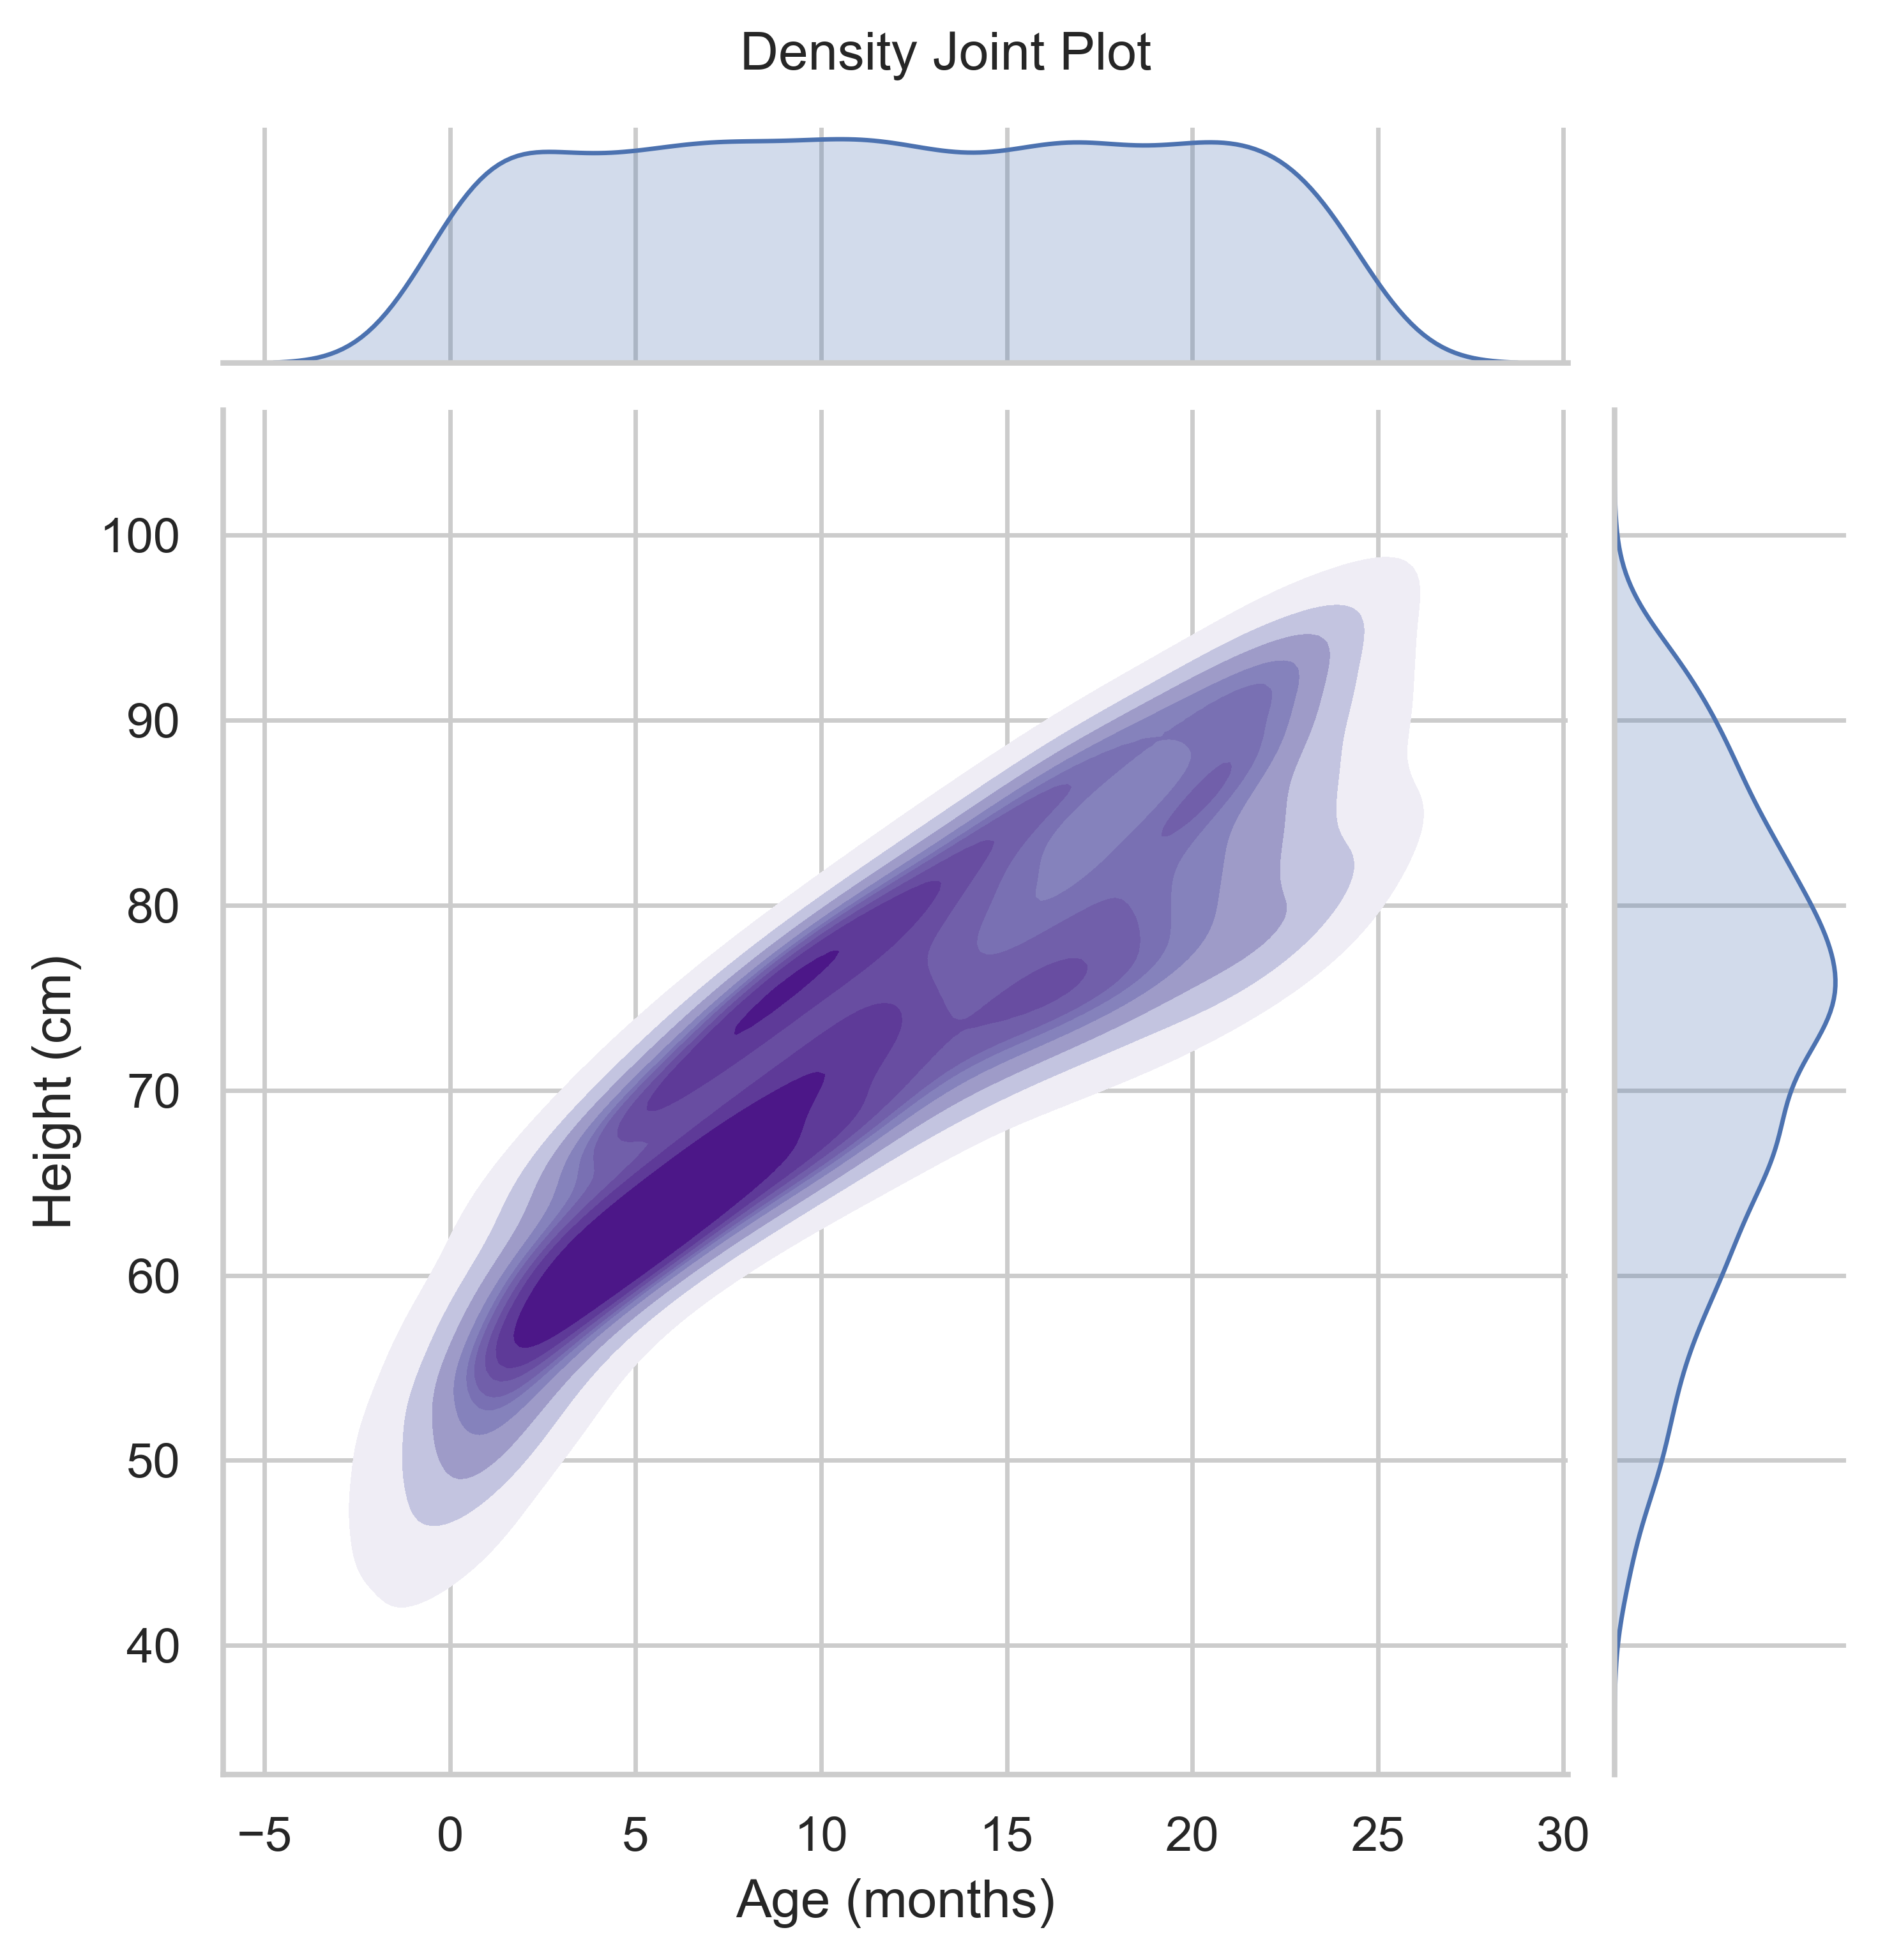

In [5]:
plt.figure(figsize=(10, 8))
g = sns.jointplot(
    data=df_final.sample(2000, random_state=42),
    x='Age (months)',
    y='Height (cm)',
    kind='kde',
    cmap='Purples',
    fill=True
)
g.fig.suptitle('Density Joint Plot', y=1.02, fontsize=12)
plt.savefig('results/regression/stunting_regression_jointplot.png', dpi=500, bbox_inches='tight')
plt.show()

## 4. Feature Decoupling and Input Preparation
To prevent *feature noise*, we decouple the inputs:
- **HAZ Features**: `Gender`, `Age`, and `Height` (excluding Weight).
- **WAZ Features**: `Gender`, `Age`, and `Weight` (excluding Height).

In [6]:
gender_encoder = LabelEncoder()
df_final['Gender_Encoded'] = gender_encoder.fit_transform(df_final['Gender'])

# Decoupled Input for HAZ
X_haz = df_final[['Gender_Encoded', 'Age (months)', 'Height (cm)']]
y_haz = df_final['HAZ']

# Decoupled Input for WAZ
X_waz = df_final[['Gender_Encoded', 'Age (months)', 'Weight (kg)']]
y_waz = df_final['WAZ']

print(f"Decoupled HAZ Features: {X_haz.columns.tolist()}")
print(f"Decoupled WAZ Features: {X_waz.columns.tolist()}")

Decoupled HAZ Features: ['Gender_Encoded', 'Age (months)', 'Height (cm)']
Decoupled WAZ Features: ['Gender_Encoded', 'Age (months)', 'Weight (kg)']


## 5. Baseline Modeling and 5-Fold Cross-Validation Evaluation
Evaluates 6 regression models to predict `HAZ` using 5-Fold Cross-Validation.

In [7]:
models_reg = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Random Forest': RandomForestRegressor(n_estimators=30, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(random_state=42, n_jobs=-1),
    'LightGBM': LGBMRegressor(random_state=42, verbose=-1, n_jobs=-1),
    'CatBoost': CatBoostRegressor(random_seed=42, verbose=0)
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
results_haz = {}

print("Evaluating HAZ Regression Model (5-Fold CV):")
for name, model in models_reg.items():
    mae_scores = []
    rmse_scores = []
    r2_scores = []

    for train_idx, val_idx in cv.split(X_haz, y_haz):
        X_tr, X_val = X_haz.iloc[train_idx], X_haz.iloc[val_idx]
        y_tr, y_val = y_haz.iloc[train_idx], y_haz.iloc[val_idx]

        model.fit(X_tr, y_tr)
        preds = model.predict(X_val)

        mae_scores.append(mean_absolute_error(y_val, preds))
        rmse_scores.append(np.sqrt(mean_squared_error(y_val, preds)))
        r2_scores.append(r2_score(y_val, preds))

    results_haz[name] = {
        'MAE': f"{np.mean(mae_scores):.6f} +/- {np.std(mae_scores):.6f}",
        'RMSE': f"{np.mean(rmse_scores):.6f} +/- {np.std(rmse_scores):.6f}",
        'R2': f"{np.mean(r2_scores):.6f} +/- {np.std(r2_scores):.6f}"
    }
    print(f"- {name} R2-Score: {np.mean(r2_scores):.6f}")

pd.DataFrame(results_haz).T

Evaluating HAZ Regression Model (5-Fold CV):
- Linear Regression R2-Score: 0.821388
- Ridge Regression R2-Score: 0.821388
- Random Forest R2-Score: 1.000000
- XGBoost R2-Score: 0.999159
- LightGBM R2-Score: 0.997572
- CatBoost R2-Score: 0.999577


,MAE,RMSE,R2
Linear Regression,0.616804 +/- 0.002632,0.832813 +/- 0.006291,0.821388 +/- 0.003024
Ridge Regression,0.616804 +/- 0.002632,0.832813 +/- 0.006291,0.821388 +/- 0.003024
Random Forest,0.000107 +/- 0.000001,0.000795 +/- 0.000093,1.000000 +/- 0.000000
XGBoost,0.042235 +/- 0.000483,0.057139 +/- 0.000827,0.999159 +/- 0.000021
LightGBM,0.075526 +/- 0.001120,0.097089 +/- 0.001474,0.997572 +/- 0.000069
CatBoost,0.026380 +/- 0.000215,0.040547 +/- 0.000363,0.999577 +/- 0.000007


## 6. Hyperparameter Optimization Using Optuna
Tunes LGBMRegressor parameters to minimize MAE of HAZ predictions.

In [8]:
X_train_h, X_val_h, y_train_h, y_val_h = train_test_split(X_haz, y_haz, test_size=0.2, random_state=42)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15),
        'num_leaves': trial.suggest_int('num_leaves', 15, 63),
        'verbose': -1,
        'random_state': 42,
        'n_jobs': -1
    }
    model = LGBMRegressor(**params)
    model.fit(X_train_h, y_train_h)
    preds = model.predict(X_val_h)
    return mean_absolute_error(y_val_h, preds)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

print("Best parameters from Optuna:")
print(study.best_params)

Best parameters from Optuna:
{'n_estimators': 102, 'max_depth': 6, 'learning_rate': 0.10281312963374978, 'num_leaves': 61}


## 7. Final Optimized Model Training and Residual Analysis
Trains the final optimized LightGBM models for HAZ and WAZ.

In [9]:
# Train the best HAZ model on all data
best_lgbm_haz = LGBMRegressor(**study.best_params, verbose=-1, random_state=42, n_jobs=-1)
best_lgbm_haz.fit(X_haz, y_haz)

# Train the best WAZ model on all data (using similar optimal parameters)
best_lgbm_waz = LGBMRegressor(**study.best_params, verbose=-1, random_state=42, n_jobs=-1)
best_lgbm_waz.fit(X_waz, y_waz)

print("Both final optimized HAZ & WAZ models trained successfully!")

Both final optimized HAZ & WAZ models trained successfully!


### 7.1 Diagnostic Residual Plots (500 DPI)
Displays the distribution of prediction errors vs. actual values and the normality of residuals.

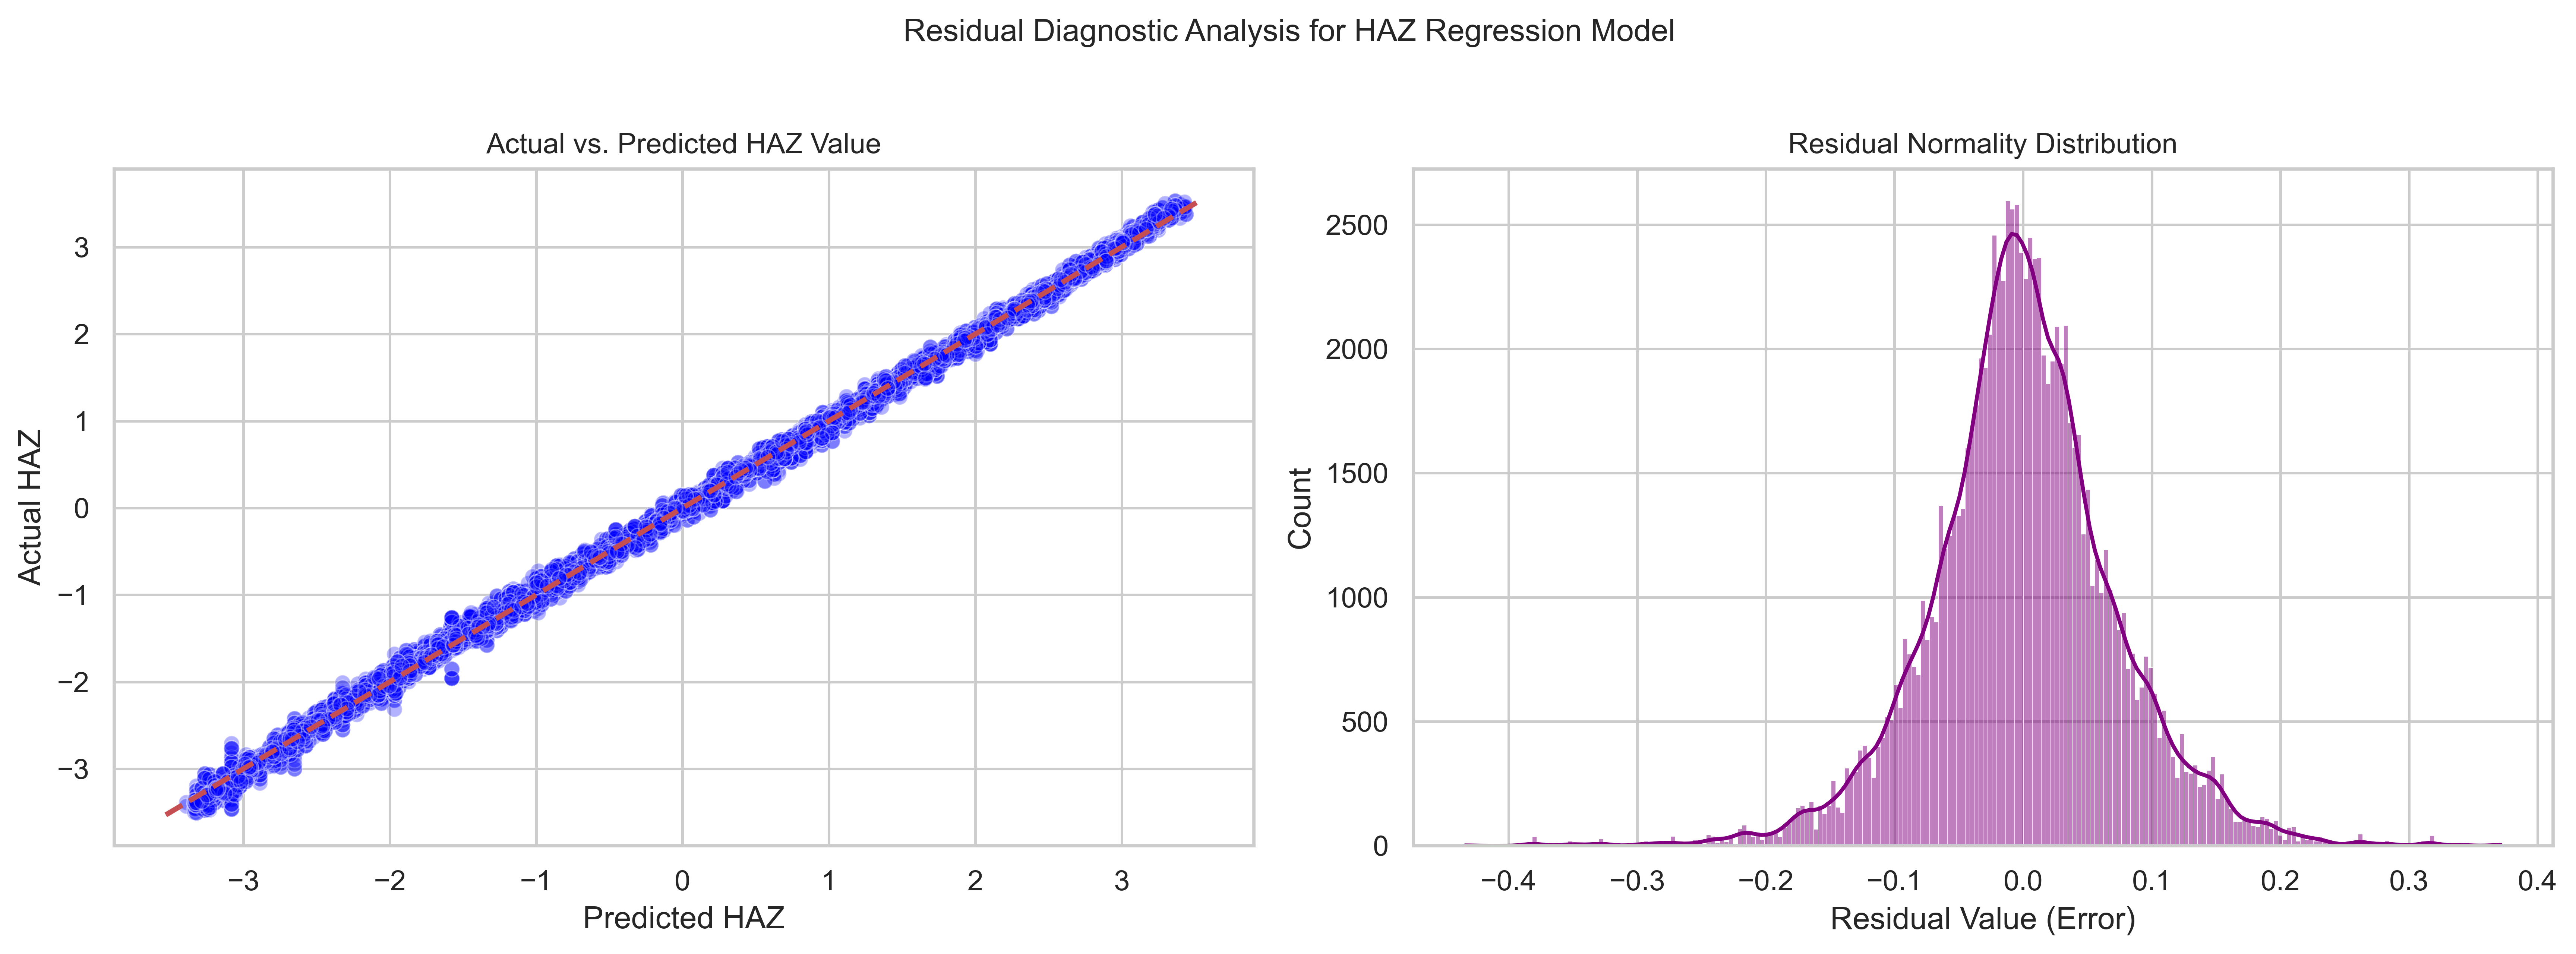

In [10]:
haz_preds = best_lgbm_haz.predict(X_haz)
residuals = y_haz - haz_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter Prediksi vs Aktual
sns.scatterplot(x=haz_preds[::10], y=y_haz[::10], alpha=0.3, ax=axes[0], color='blue')
axes[0].plot([y_haz.min(), y_haz.max()], [y_haz.min(), y_haz.max()], 'r--', lw=2)
axes[0].set_title('Actual vs. Predicted HAZ Value', fontsize=11)
axes[0].set_xlabel('Predicted HAZ')
axes[0].set_ylabel('Actual HAZ')

# Distribusi Residu
sns.histplot(residuals, kde=True, ax=axes[1], color='purple')
axes[1].set_title('Residual Normality Distribution', fontsize=11)
axes[1].set_xlabel('Residual Value (Error)')

plt.suptitle('Residual Diagnostic Analysis for HAZ Regression Model', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('results/regression/regression_residual_analysis.png', dpi=500, bbox_inches='tight')
plt.show()

## 8. Feature Contribution Analysis Using SHAP
Explains global and local feature importance towards HAZ score predictions.

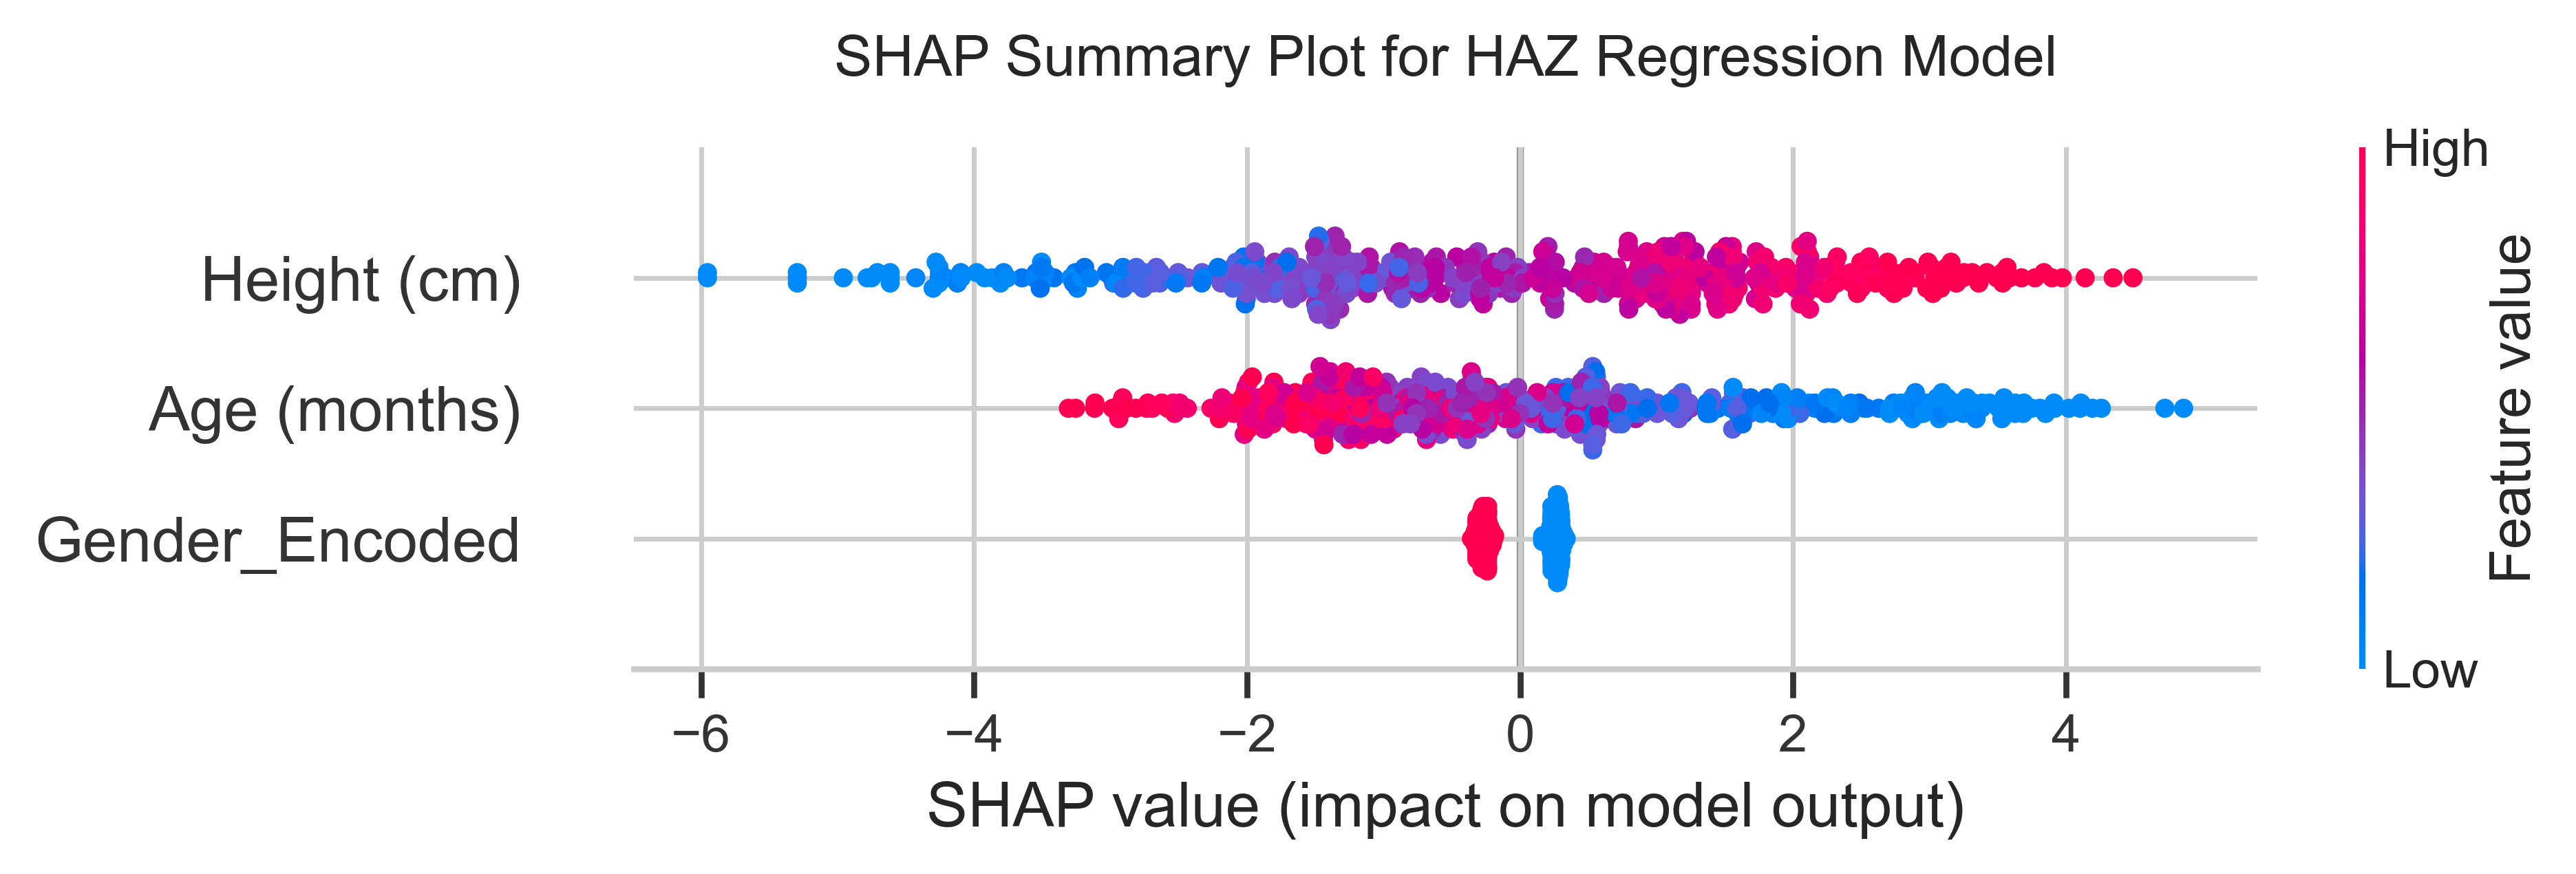

In [11]:
explainer = shap.TreeExplainer(best_lgbm_haz)
X_sample = X_haz.sample(500, random_state=42)
shap_values = explainer(X_sample)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title('SHAP Summary Plot for HAZ Regression Model', fontsize=12, pad=15)
plt.tight_layout()
plt.savefig('results/regression/regression_shap_summary.png', dpi=500, bbox_inches='tight')
plt.show()

## 9. Model Serialization and Z-Score Regression Inference Pipeline (MLOps)
Saves the trained HAZ and WAZ regression models and provides an integrated prediction function with input validation.

In [12]:
# Save the regression models
joblib.dump(best_lgbm_haz, 'results/regression/stunting_lgbm_reg_haz.joblib')
joblib.dump(best_lgbm_waz, 'results/regression/stunting_lgbm_reg_waz.joblib')
print("HAZ & WAZ regression models saved successfully to results/regression/!")

# Self-Inference Pipeline with GIGO Protection
def estimate_z_score(gender, age_months, height_cm, weight_kg):
    # 1. Proteksi batas biologis input
    if not (0 <= age_months <= 60):
        raise ValueError("Child's age must be within the biological range of 0 to 60 months.")
    if not (30 <= height_cm <= 120):
        raise ValueError("Height must be within the biological range of 30 to 120 cm.")
    if not (2 <= weight_kg <= 30):
        raise ValueError("Weight must be within the biological range of 2 to 30 kg.")
    if gender not in ['Male', 'Female']:
        raise ValueError("Gender must be 'Male' or 'Female'.")

    # 2. Transformasi input
    gender_enc = gender_encoder.transform([gender])[0]

    # 3. Prediksi HAZ (Decoupled)
    input_haz = pd.DataFrame([{
        'Gender_Encoded': gender_enc,
        'Age (months)': age_months,
        'Height (cm)': height_cm
    }])
    pred_haz = best_lgbm_haz.predict(input_haz)[0]

    # 4. Prediksi WAZ (Decoupled)
    input_waz = pd.DataFrame([{
        'Gender_Encoded': gender_enc,
        'Age (months)': age_months,
        'Weight (kg)': weight_kg
    }])
    pred_waz = best_lgbm_waz.predict(input_waz)[0]

    return pred_haz, pred_waz

# Test example for new regression inference
haz_val, waz_val = estimate_z_score(gender='Female', age_months=24, height_cm=82.0, weight_kg=10.5)
print(f"Child Z-Score Estimation - HAZ: {haz_val:.4f}, WAZ: {waz_val:.4f}")

HAZ & WAZ regression models saved successfully to results/regression/!
Child Z-Score Estimation - HAZ: -1.1889, WAZ: -0.7290


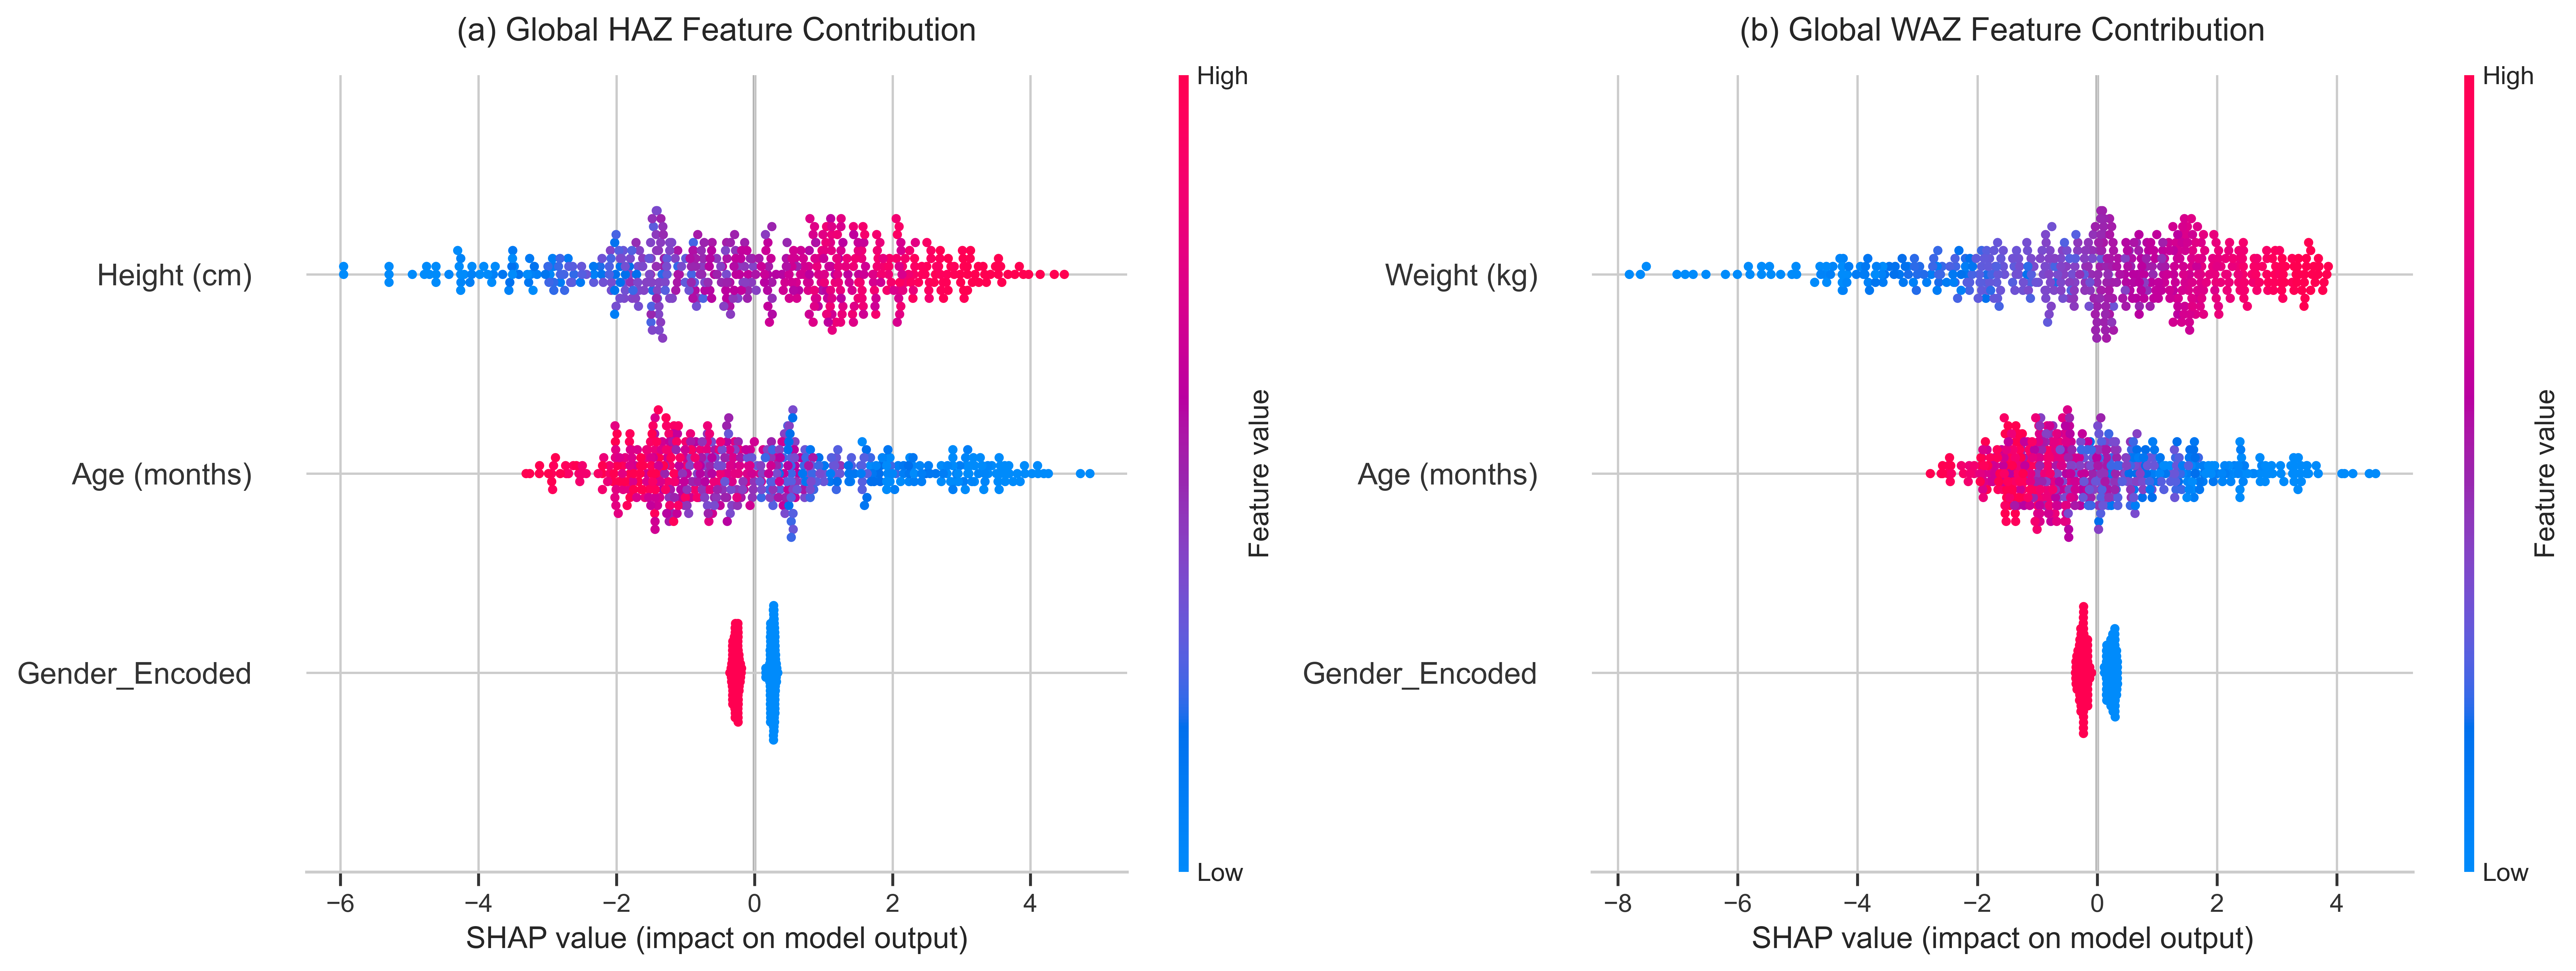

In [13]:
import matplotlib.pyplot as plt
import shap

# Ensure explainer is created for both models
explainer_haz = shap.TreeExplainer(best_lgbm_haz)
explainer_waz = shap.TreeExplainer(best_lgbm_waz)

# Subsample for faster computation and cleaner visualization
X_sample_haz = X_haz.sample(500, random_state=42)
X_sample_waz = X_waz.sample(500, random_state=42)

shap_values_haz = explainer_haz(X_sample_haz)
shap_values_waz = explainer_waz(X_sample_waz)

# Create a canvas for 2 side-by-side plots
fig = plt.figure(figsize=(16, 6))

# --- (a) Subplot for HAZ ---
plt.subplot(1, 2, 1)
shap.summary_plot(shap_values_haz, X_sample_haz, show=False, plot_size=None)
plt.title('(a) Global HAZ Feature Contribution', fontsize=14, pad=15)

# --- (b) Subplot for WAZ ---
plt.subplot(1, 2, 2)
shap.summary_plot(shap_values_waz, X_sample_waz, show=False, plot_size=None)
plt.title('(b) Global WAZ Feature Contribution', fontsize=14, pad=15)

# Save the figure with IEEE standard (DPI 500 and without title)
plt.tight_layout()
plt.savefig('results/regression/shap_summary_komparasi.png', dpi=500, bbox_inches='tight')
plt.show()